* DSC 550-T301 Data Mining
* Week 4 Exercise
* Peter Lozano

# 1. Load the data as a Pandas DataFrame and ensure that it imported correctly.

## Import packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv("Data/auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


# 2. Begin by prepping the dat for modeling:
    a. Remove the car name column.
    b. The horsepower column values likely imported as a string data type. Figure out why and replace any strings with the column mean.
    c. Create dummy variables for the origin column.

Horsepower column did convert into a string and most likley contains some non-numeric values that need to be replaced with the column mean.

Let me find out what exactly I'm changing first.

In [3]:
# Find non numeric value in horsepower column
df[pd.to_numeric(df["horsepower"], errors="coerce").isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,?,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,?,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,?,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,?,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,?,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,?,3035,20.5,82,1,amc concord dl


Ok, I can see that it is simply typed in as a "?" for unknown values. I feel confident now that replacing the non-numeric values in the horsepower column with the column mean is the correct approach.

In [4]:
# Remove car name column
df = df.drop(columns=["car name"])

# Convert horsepower column to numeric, replacing non-numeric values with the column mean
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].mean())

# Create dummy variables for the origin column
df = pd.get_dummies(df, columns=["origin"], drop_first=True)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,70,False,False
1,15.0,8,350.0,165.0,3693,11.5,70,False,False
2,18.0,8,318.0,150.0,3436,11.0,70,False,False
3,16.0,8,304.0,150.0,3433,12.0,70,False,False
4,17.0,8,302.0,140.0,3449,10.5,70,False,False


A simple drop operation in pandas handles the removal of the `car name` column.

I converted `horsepower` to a numeric type to perform numerical operations on it (mean) first. This causes any non-numeric values to be converted to `NaN`. After that, I can simply fill the `NaN` values with the mean of the column.

Lastly, I created dummy columns based on the `origin` column to handle categorical data. Pandas provides the `get_dummies` function to easily convert categorical variables by creating separate binary columns for each category. This resulted in splitting the `origin` column into 2 separate columns, each representing a unique category from within.

# 3. Create a correlation coefficient matrix and/or visualization. Are there features highly correlated with mpg?

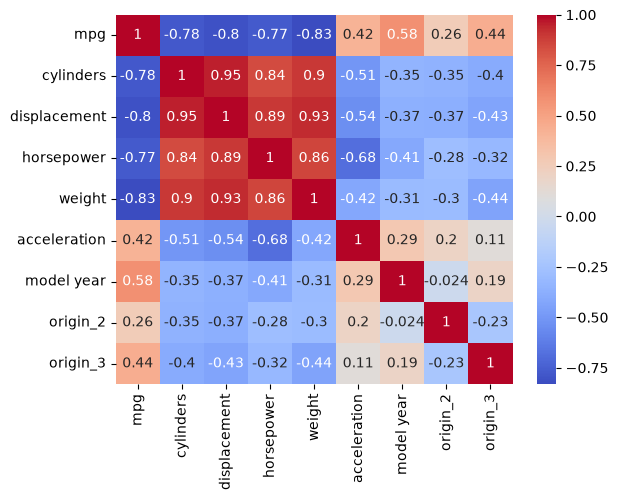

In [5]:
# Correlation coefficient matrix
correlation_matrix = df.corr()

# Heatmap of the correlation matrix
sns.heatmap(
    correlation_matrix, 
    annot=True,
    cmap='coolwarm'
)

plt.show()


Based on the results of the correlation matrix and heatmap, I can clearly see that the `cylinders`, `displacement`, `horsepower`, and `weight` features are highly correlated with `mpg`. The rest of the features do not show a strong correlation in comparison. I also don't want to introduce too many features with a linear model because it can have multicollinearity issues, which can negatively impact the model's performance and interpretability.

# 4. Plot mpg versus weight. Analyze this graph and explain how it relates to the corresponding correlation coefficient.

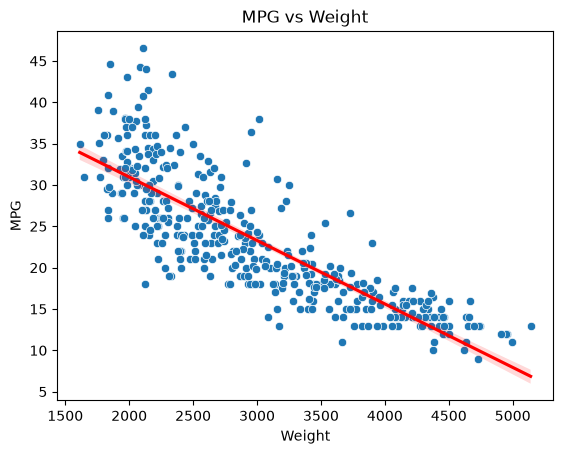

In [6]:
# Plot mpg versus weight and analyze the relationship
sns.scatterplot(
    data=df,
    x='weight', # Independent variable
    y='mpg', # Dependent variable
)

# Adding a trend line
sns.regplot(
    data=df,
    x='weight',
    y='mpg',
    scatter=False,
    color='red' # For contrast
)

plt.title('MPG vs Weight')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.show()

Trend line is not necessary as the relationship between `mpg` and `weight` is already clearly visible from the scatter plot. As I can see, there is a strong negative correlation between `mpg` and `weight`, meaning that as the weight of the car increases, the `mpg` tends to decrease.

However, I can see that there is a wider spread of `mpg` values for cars with weights around the **2,000 to 3,000 lbs** range. This indicates that a regression model might have more difficulty accurately predicting `mpg` for cars within this weight range.

# 5. Randomly split the data into 80% training data and 20% test data, where your target is mpg.

In [7]:
# Drop the target column 'mpg' from the features
X = df.drop(columns='mpg')

# Assign the target column 'mpg'
y = df['mpg']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, # Assigned to X_train and X_test
    y, # Assigned to y_train and y_test
    test_size=0.2, # 20% for the test set
    random_state=42 # Ensures reproducibility of the split
)

So, what I have done here is split my data set into 2 parts: a training set and a test set. The training set is used to train the linear regression model, and the test set is used to evaluate its performance.

The test set will have the answer (`mpg`) which is what I will use to compare against the model's predictions (`y_pred`).

I also have set the `random_state` parameter in the `train_test_split` function so that this set is repeatable.

# 6. Train an ordinary linear regression on the training data.

For linear regression models, the goal is to find the best-fitting line that minimizes the sum of the squared differences between the observed values and the predicted values. This line is represented by the equation:

$ y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n $

Where:

* ($y$) is the dependent variable that we are trying to predict

* \( $x_1$, $x_2$, $\dots$, $x_n$ \) are the independent variables that we use to predict the dependent variable

* And ($\beta_0$, $\beta_1$, $\dots$, $\beta_n$) are the coefficients estimated by the model

I have a couple ways to evaluate the model's performance but, I have to remember that based on the spread of `mpg` values for cars with a specific weight range can affect the accuracy of the predictions. So, **Root Mean Squared Error (RMSE)** would penalize larger errors more heavily and give a better indication of the model's predictive accuracy.

On the other hand, **Mean Absolute Error (MAE)** treats all errors equally and provides a more straightforward interpretation of the average error magnitude. 

Lastly, **R-squared (R²)** measures the percentage of the variance in the dependent variable ($y$) that is predictable from the independent variables ($x_i$), giving an overall indication of the model's goodness of fit.

In [8]:
# Initialize the linear regression model
model = LinearRegression()

# Fit the model on the training data
model.fit(X_train, y_train)

# Predict on the test data
y_pred = model.predict(X_test) # predicts by using coe

After I initialize the `LinearRegression` model, I fit it to the training datasets which makes it "learn" or determine the best-fitting coefficients (weights) for the features ($x_n$).

Now I pass the `predict` method to the test features (`X_test`) to generate predictions that I pass to `y_pred`.

These predictions are then compared to the actual values (`y_test`) to evaluate the model's performance using metrics such as RMSE, MAE, and R^2 score.

Now it's time to see how the model performs...

# 7. Calculate $R^2$, RMSE, and MAE on both the training and test sets and interpret your results.

In [9]:
# Root mean squared error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Mean absolute error
mae = mean_absolute_error(y_test, y_pred)

# R-squared score
r2 = r2_score(y_test, y_pred)

# Print results
print("--- Linear Regression Results ---")
print(f"Root Mean Squared Error: {round(rmse, 3)}")
print(f"Mean Absolute Error: {round(mae, 3)}")
print(f"R\u00b2 Score: {round(r2, 3)}")

--- Linear Regression Results ---
Root Mean Squared Error: 2.888
Mean Absolute Error: 2.288
R² Score: 0.845


What is great about this approach is that it allows me to understand the best and worst case scenarios for my model's predictions. I can interpret these results based on actual units of measurement here. For example, if the actual car had an `mpg` of 30, my model might predict an `mpg` in the range of 28 to 32!

The **RMSE** is providing me the worst case scenario for my model's prediction errors which may be what a business is most concerned about, particularly if it is more detrimental to have large errors. This is due to it squaring the errors before averaging, which gives more weight to larger errors. On the other hand, the **MAE** gives me the average magnitude of the errors without considering their direction, providing a more straightforward interpretation of the typical prediction error.

The **R^2 score** of **~85%** indicates that my model explains approximately 85% of the variance in the target variable (`mpg`). This suggests that the model has a good fit to the data, capturing most of the underlying patterns, although there is still some unexplained variance.

# 8. Pick another regression model and repeat the previous two steps.
**Note**: Do NOT choose logistic regression as it is more like a classification model.

Since I get to chose a regression model, I will stick with using the [scikit-learn](https://scikit-learn.org/stable/modules/linear_model.html) library and chose the Lasso regression model.

I'm chosing this model because it helps with feature selection by shrinking some coefficients to zero, which can improve the interpretability of the model and prevent overfitting. This is something the prior model doesn't do, making Lasso regression a more robust choice for datasets with many features.

There is also the Ridge regression model, which is similar to Lasso but it penalizes the coefficients using the L2 norm instead of the L1 norm. This means Ridge regression shrinks the coefficients towards zero but none exactly to zero, so each feature still contributes to the model, albeit with smaller weights.

Lasso regression, does shrink some coefficients exactly to zero, effectively performing feature selection. This can be useful with datasets that are heavy with features because it helps in identifying the most important ones and reducing model complexity.

To begin, I need to import Lasso from scikit-learn and also pass the alpha ($\alpha$) parameter, which controls the strength of the regularization (the penalty applied to the coefficients).

In [10]:
from sklearn.linear_model import Lasso

# Initialize the Lasso regression model
# The alpha parameter controls the strength of the penalty
lasso_model = Lasso(alpha=0.001) # Starting with 0.001

The scikit-learn documentation provides an example with ($\alpha$) at **0.5**. This can be used as a reference point, but the optimal ($\alpha$) value may vary depending on the specific dataset and should be tuned accordingly. I'm not sure what the best ($\alpha$) value is for my dataset, so I will start with **0.001** and adjust if necessary based on model performance.

Now I fit the Lasso regression model on the training data and train it to learn the relationships between the features and the target variable.

In [11]:
# Fit the model on the exact same training data
lasso_model.fit(X_train, y_train)

# Predict on the blind test data
lasso_pred = lasso_model.predict(X_test)

Now I'm ready to evaluate the performance of the Lasso regression model on the test data.

In [12]:
# Calculate the metrics to compare against your baseline
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("--- Lasso Regression Results ---")
print(f"RMSE: {round(lasso_rmse, 3)}")
print(f"MAE: {round(lasso_mae, 3)}")
print(f"R^2 Score: {round(lasso_r2, 3)}")

--- Lasso Regression Results ---
RMSE: 2.888
MAE: 2.288
R^2 Score: 0.845


It faired no better than the baseline model. I have also tested this against a higher ($\alpha$) value, but the performance was worse.

It goes to show that the *cooler* a regression model may seem, it doesn't necessarily guarantee better performance on a given dataset. I have fundamentally turned off the penalization by setting a very low ($\alpha$) value, which essentially makes the Lasso regression behave like a standard linear regression model. This highlights the importance of model selection and hyperparameter tuning in achieving optimal performance.